# Pretrain

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset
import math
from functools import partial

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, patches, embed_dim):
        super().__init__()
        self.d_k = embed_dim
        self.patches = patches
        pe = torch.zeros(patches, self.d_k)
        div = torch.exp(torch.arange(0, self.d_k, 2).float() * -(math.log(10000.0) / self.d_k))
        position = torch.arange(0, patches).float().unsqueeze(1)
        pe[:, 0::2] = torch.sin(position * div)
        pe[:, 1::2] = torch.cos(position * div)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    
    def forward(self, x):
        return x + self.pe[:, :self.patches, :].detach()

In [3]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        x = self.proj(x)  # (B, embed_dim, h/p, w/p)
        x = x.flatten(2).transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


In [4]:
class MultiheadAttention(nn.Module): # linear attention 
    def __init__(self,embed_dim,head):
        super().__init__()
        self.head = head
        self.head_dim = embed_dim // self.head 
        assert self.head * self.head_dim == embed_dim
        self.Q = nn.Linear(embed_dim,embed_dim)
        self.K = nn.Linear(embed_dim,embed_dim)
        self.V = nn.Linear(embed_dim,embed_dim)
        pass
    def feature_map(self,x):
        return F.gelu(x)
    def forward(self,x):
        # linear kernel
        B,L,E = x.size()
        q = self.Q(x).view(B,L,self.head,self.head_dim).transpose(2,1) # (32,156,200) = (32,156,4,50) = (32,4,156,50)
        k = self.K(x).view(B,L,self.head,self.head_dim).transpose(2,1) 
        v = self.V(x).view(B,L,self.head,self.head_dim).transpose(2,1) 
        k_t = self.feature_map(k.transpose(-1,-2))
        q = self.feature_map(q)
        kv = torch.matmul(k_t,v)
        num = torch.matmul(q,kv)
        z = k.sum(dim=2,keepdim=True).transpose(-1,-2)
        denom = torch.matmul(q,z)
        out = num / (denom + 1e-4)
        out = out.transpose(1, 2).reshape(B, L, E)
        return out

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads,mlp_ratio=4.0, qkv_bias=True, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(embed_dim)
        self.attn = MultiheadAttention(embed_dim, num_heads)
        self.norm2 = norm_layer(embed_dim)
        mlp_hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(mlp_hidden_dim, embed_dim),
            nn.Dropout(0.1)
        )
    
    def forward(self, x):
        # Self-attention
        attn_out= self.attn(self.norm1(x))
        x = x + attn_out # residual 1
        # MLP
        x = x + self.mlp(self.norm2(x)) # residual 2
        return x

def create_encoder_blocks(embed_dim, depth, num_heads):
    return nn.ModuleList([
        TransformerBlock(embed_dim, num_heads)
        for _ in range(depth)
    ])

def create_decoder_blocks(embed_dim, depth, num_heads):
    return nn.ModuleList([
        TransformerBlock(embed_dim, num_heads)
        for _ in range(depth)
    ])


In [6]:
class MaskedAutoencoderViT(nn.Module):
    def __init__(self, img_size=125, patch_size=5, in_chans=8,
                 encoder_embed_dim=200, encoder_depth=12, encoder_num_heads=4,
                 decoder_embed_dim=100, decoder_depth=8, decoder_num_heads=2,
                 mlp_ratio=4.,norm_pix_loss=False):
        
        super().__init__()
        
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, encoder_embed_dim)
        self.num_patches = self.patch_embed.num_patches
        # Encoder positional encoding (no cls token)
        self.encoder_pos_embed = PositionalEncoding(self.num_patches, encoder_embed_dim)
        # Encoder
        self.encoder_blocks = create_encoder_blocks(encoder_embed_dim, encoder_depth, encoder_num_heads)
        self.encoder_norm = nn.LayerNorm(encoder_embed_dim)
        # Decoder embedding
        self.encoder_to_decoder = nn.Linear(encoder_embed_dim, decoder_embed_dim, bias=True)
        # Decoder positional encoding (includes cls token position)
        self.decoder_pos_embed = PositionalEncoding(self.num_patches, decoder_embed_dim)
        # Decoder mask token and blocks
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_embed_dim)) # 625 - 156 = 469
        self.decoder_blocks = create_decoder_blocks(decoder_embed_dim, decoder_depth, decoder_num_heads)
        self.decoder_norm = nn.LayerNorm(decoder_embed_dim)
        # Final prediction head
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * in_chans, bias=True) # to take back to image 
        self.norm_pix_loss = norm_pix_loss
        self.initialize_weights() # getting and Xavier weight 
    
    def initialize_weights(self):
        # Initialize encoder to decoder projection
        nn.init.xavier_uniform_(self.encoder_to_decoder.weight)
        nn.init.constant_(self.encoder_to_decoder.bias, 0)
        
        # Initialize mask token
        nn.init.normal_(self.mask_token, std=0.02)
        
        # Initialize decoder prediction head
        nn.init.xavier_uniform_(self.decoder_pred.weight)
        nn.init.constant_(self.decoder_pred.bias, 0)
        
        # Apply weight init to all layers
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
    
    def patchify(self, imgs):
        p = self.patch_embed.patch_size
        C = imgs.shape[1]  
        h, w = imgs.shape[2] // p, imgs.shape[3] // p
        x = imgs.reshape(shape=(imgs.shape[0], C, h, p, w, p))  # channels = 8
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * C))  
        return x

    
    def unpatchify(self, x): # to convert the patches = images 
        p = self.patch_embed.patch_size
        h, w = int(x.shape[1]**0.5), int(x.shape[1]**0.5)
        x = x.reshape(shape=(x.shape[0], h, w, p, p, 3))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], 3, h * p, h * p))
        return imgs
    
    def random_masking(self, x, mask_ratio): # random masking 
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1) # to get the location for un masking 
        
        ids_keep = ids_shuffle[:, :len_keep] # reducing the seq_len(num_patches) => 0.75 = 156
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore
    
    def forward_encoder(self, x, mask_ratio):
        x = self.patch_embed(x) # converting to patches 
        x = self.encoder_pos_embed(x) # positionally encoded 
        x_masked, mask, ids_restore = self.random_masking(x, mask_ratio) # random masking with uniform dist
        for block in self.encoder_blocks: # iteerating to depth of transformer blocks 
            x_masked = block(x_masked)
        x_encoded = self.encoder_norm(x_masked)
        
        return x_encoded, mask, ids_restore
    
    def forward_decoder(self, x_encoded, ids_restore):
        x_dec = self.encoder_to_decoder(x_encoded)  # [B, len_keep, decoder_dim]
        num_mask_tokens = ids_restore.shape[1] - x_dec.shape[1]  # Should be 625 - 156 = 469
        mask_tokens = self.mask_token.repeat(x_dec.shape[0], num_mask_tokens, 1) # here the 469 mask tokens are created 
        
        # Unshuffle: reconstruct full sequence
        x_ = torch.cat([x_dec, mask_tokens], dim=1)  # [B, 625, decoder_dim] # mask tokens are readded
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x_dec.shape[2]))
        x_dec = self.decoder_pos_embed(x_)  # [B, 625, decoder_dim] = positional encoding 
        
        # Decoder transformer blocks
        for block in self.decoder_blocks:
            x_dec = block(x_dec)
        x_dec = self.decoder_norm(x_dec)
        
        # Final prediction
        x_pred = self.decoder_pred(x_dec)  # [B, 625, patch_size²×in_chans]
        
        return x_pred 

    
    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1.e-6)**0.5
        
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()  # Mean loss on masked patches
        return loss
    
    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask


In [7]:
# for this offical refrence are taken 
def mae_small(**kwargs):
    model = MaskedAutoencoderViT(
        encoder_embed_dim=200, encoder_depth=6, encoder_num_heads=4,
        decoder_embed_dim=100, decoder_depth=4, decoder_num_heads=2,
        mlp_ratio=4,**kwargs)
    return model
# Set recommended architectures
mae = mae_small

In [8]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = mae(img_size=125, patch_size=5).to(device)

# Dummy input
x = torch.randn(2,8,125,125).to(device)
loss, pred, mask = model(x)

print(f"Input shape: {x.shape}")
print(f"Prediction shape: {pred.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Reconstruction loss: {loss.item():.4f}")


Input shape: torch.Size([2, 8, 125, 125])
Prediction shape: torch.Size([2, 625, 200])
Mask shape: torch.Size([2, 625])
Reconstruction loss: 1.6542


In [9]:
import h5py
from torch.utils.data import Dataset

class H5Dataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path
        self.f = h5py.File(file_path, 'r')  
        self.jet = self.f['jet']  

    def __getitem__(self, index):
        data = self.jet[index]  
        tensor = torch.from_numpy(data).float()
        return tensor.permute(2, 0, 1)  # Assumes (H,W,C) -> (C,H,W)

    def __len__(self):
        return len(self.jet)

    def __del__(self):  
        self.f.close()


In [12]:
dataset = H5Dataset("/media/pvg/1CB89C4BB89C24F4/CERN_DATA/Dataset_Specific_Unlabelled.h5")

In [13]:
from torch.utils.data import random_split

# Calculate lengths
total_size = len(dataset) # 60,000
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Create the subsets (This is memory-efficient!)
train_subset, val_subset, test_subset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) # For reproducibility
)

In [14]:
batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2)

In [15]:
from tqdm.notebook import tqdm,trange

In [16]:
num_epochs = 20
lr = 2e-4
weight_decay = 0.05
eps = 1e-8
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
    eps=eps
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
optimizer,mode="min",patience=2
,)

Exception ignored in: <function H5Dataset.__del__ at 0x78ed4014a700>
Traceback (most recent call last):
  File "/tmp/ipykernel_5941/2107094525.py", line 19, in __del__
AttributeError: 'H5Dataset' object has no attribute 'f'


In [17]:
model

MaskedAutoencoderViT(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(8, 200, kernel_size=(5, 5), stride=(5, 5))
  )
  (encoder_pos_embed): PositionalEncoding()
  (encoder_blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (norm1): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (Q): Linear(in_features=200, out_features=200, bias=True)
        (K): Linear(in_features=200, out_features=200, bias=True)
        (V): Linear(in_features=200, out_features=200, bias=True)
      )
      (norm2): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=200, out_features=800, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=800, out_features=200, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (encoder_norm): LayerNorm((200,), eps=1e-05, elementwise_affine=True)
  (encoder_to_decoder): L

In [18]:
torch.cuda.empty_cache()

In [19]:
import os
import torch
from datetime import datetime

model = model.to(device)
train_losses = []
val_losses = []

# Create checkpoint directory
checkpoint_dir = "checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

best_val_loss = float('inf')
patience = 2
patience_counter = 0
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for epoch in range(num_epochs):
    # Train
    model.train()
    train_loss = 0
    
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Train")
    
    for images in train_loop:
        images = images.to(device, non_blocking=True)
        
        mean = images.mean(dim=[0,2,3], keepdim=True)
        std = images.std(dim=[0,2,3], keepdim=True) + 1e-6
        images = (images - mean) / std
        
        optimizer.zero_grad()
        loss, pred, mask = model(images)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_loop.set_postfix(loss=f"{loss.item():.4f}")
    
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    val_loss = 0
    
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Val")
    
    with torch.no_grad():
        for images in val_loop:
            images = images.to(device, non_blocking=True)
            
            mean = images.mean(dim=[0,2,3], keepdim=True)
            std = images.std(dim=[0,2,3], keepdim=True) + 1e-6
            images = (images - mean) / std
            
            loss, pred, mask = model(images)
            val_loss += loss.item()
            val_loop.set_postfix(loss=f"{loss.item():.4f}")
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}")
    
    # Save checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = os.path.join(checkpoint_dir, f"mae_epoch_{epoch+1:03d}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'avg_train_loss': avg_train_loss,
            'avg_val_loss': avg_val_loss,
        }, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")
    
    # Save best model and early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_path = os.path.join(checkpoint_dir, f"mae_best_{timestamp}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
        }, best_path)
        print(f"New best model saved: {best_path} (Val loss: {best_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

# Final save
final_path = os.path.join(checkpoint_dir, f"mae_final_{timestamp}.pth")
torch.save({
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
}, final_path)
print(f"Final model saved: {final_path}")

# Save loss history as numpy arrays for later analysis
import numpy as np
np.save(os.path.join(checkpoint_dir, f"train_losses_{timestamp}.npy"), np.array(train_losses))
np.save(os.path.join(checkpoint_dir, f"val_losses_{timestamp}.npy"), np.array(val_losses))
print("Loss history saved as .npy files")

Epoch 1/20 Train:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/20 Val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1: Train=1.0275, Val=0.9793
New best model saved: checkpoints/mae_best_20260323_151144.pth (Val loss: 0.9793)


Epoch 2/20 Train:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/20 Val:   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch 10/20 Val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10: Train=0.9194, Val=0.9196
Checkpoint saved: checkpoints/mae_epoch_010.pth


Epoch 11/20 Train:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 11/20 Val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 11: Train=0.9175, Val=0.9193
Early stopping triggered at epoch 11.
Final model saved: checkpoints/mae_final_20260323_151144.pth
Loss history saved as .npy files


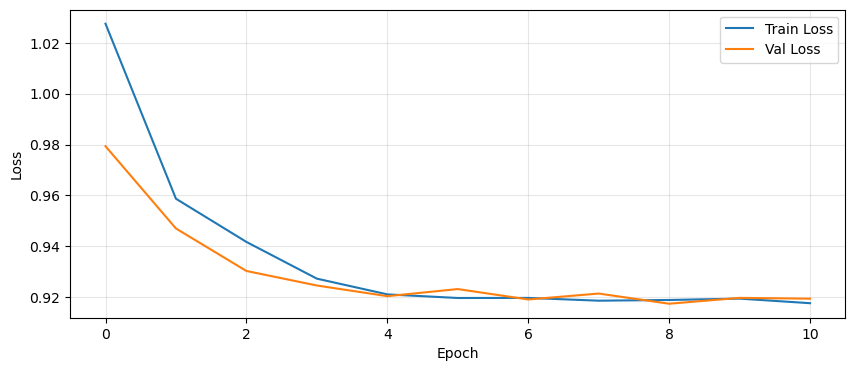

In [20]:
import matplotlib.pyplot as plt
# Plot
plt.figure(figsize=(10,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Fine Tune (classification)

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [30]:
class MAEEncoder(nn.Module):
    def __init__(self, pretrained_mae):
        super().__init__()
        self.patch_embed = pretrained_mae.patch_embed
        self.encoder_pos_embed = pretrained_mae.encoder_pos_embed
        self.encoder_blocks = pretrained_mae.encoder_blocks
        self.encoder_norm = pretrained_mae.encoder_norm
        self.num_patches = pretrained_mae.num_patches
    
    def forward_features(self, x):
        x = self.patch_embed(x)
        x = self.encoder_pos_embed(x)
        for block in self.encoder_blocks:
            x = block(x)
        x = self.encoder_norm(x)
        return x.mean(dim=1)
    
    def forward(self, x):
        return self.forward_features(x)


In [31]:
class ClassificationHead(nn.Module):
    def __init__(self, encoder_dim=200, num_classes=2):  # Changed from 384 to 200
        super().__init__()
        self.shared = nn.Sequential(
            nn.LayerNorm(encoder_dim),  # Now expects [B, 200]
            nn.Linear(encoder_dim, 512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        self.classifier = nn.Linear(256, num_classes)
    
    def forward(self, features):
        shared = self.shared(features)
        cls_logits = self.classifier(shared)
        return cls_logits

In [32]:
# fine tune model is set 
class MAE_Finetune(nn.Module):
    def __init__(self, pretrained_mae_path, img_size=125, patch_size=5, in_chans=8, 
                 num_classes=2, freeze_encoder=True):
        super().__init__()
        # Load pretrained MAE
        checkpoint = torch.load(pretrained_mae_path, map_location='cpu')
        pretrained_mae = mae(img_size=img_size, patch_size=patch_size, in_chans=in_chans)
        pretrained_mae.load_state_dict(checkpoint['model_state_dict'])
        
        # Extract encoder
        self.encoder = MAEEncoder(pretrained_mae)
        
        # Multi-task head
        self.head = ClassificationHead(encoder_dim=200, num_classes=num_classes)  # Adjust for small/base
        
        # Freeze encoder (optional - better for small datasets)
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
        
    def forward(self, x):
        features = self.encoder(x)
        cls_logits = self.head(features)
        return cls_logits
    
    def get_encoder_features(self, x):
        return self.encoder.forward_features(x)


In [25]:
class H5Dataset_fine(Dataset):
    def __init__(self, file_path, transform=None):
        self.file_path = file_path
        self.transform = transform
        
    def __getitem__(self, index):
        with h5py.File(self.file_path, 'r') as f:
            jet_data = f['jet'][index]
            label = f['Y'][index]
        
        jet_tensor = torch.from_numpy(jet_data).float()
        
        if jet_tensor.dim() == 3 and jet_tensor.shape[-1] == 8:
            jet_tensor = jet_tensor.permute(2, 0, 1)
        elif jet_tensor.shape[0] != 8:
            raise ValueError(f"Expected 8-channel input, got {jet_tensor.shape}")
        
        label = torch.tensor(label, dtype=torch.float32)
        
        if self.transform:
            jet_tensor = self.transform(jet_tensor)
            
        return jet_tensor, label
    
    def __len__(self):
        with h5py.File(self.file_path, 'r') as f:
            return len(f['jet'])


In [26]:
dataset = H5Dataset_fine("/media/pvg/1CB89C4BB89C24F4/CERN_DATA/Dataset_Specific_labelled.h5")

In [27]:
def create_dataloaders(h5_path, batch_size=16, val_split=0.2, num_workers=0):
    full_dataset = H5Dataset_fine(h5_path)
    
    n_samples = len(full_dataset)
    n_val = int(n_samples * val_split)
    n_train = n_samples - n_val
    
    train_dataset, val_dataset = random_split(
        full_dataset, 
        [n_train, n_val],
        generator=torch.Generator().manual_seed(42)
    )
    
    print(f"Split: Train={n_train}, Val={n_val}")
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, full_dataset

train_loader, val_loader, full_dataset = create_dataloaders(
    "/media/pvg/1CB89C4BB89C24F4/CERN_DATA/Dataset_Specific_labelled.h5",
    batch_size=16,
    val_split=0.2,
    num_workers=0
)

for images, labels in train_loader:
    print(f"Batch shape: Images={images.shape}, Labels={labels.shape}")
    print(f"Labels: {labels[:5]}")
    break



Split: Train=8000, Val=2000
Batch shape: Images=torch.Size([16, 8, 125, 125]), Labels=torch.Size([16, 1])
Labels: tensor([[1.],
        [0.],
        [0.],
        [1.],
        [0.]])


In [38]:
def train_classifier_model(model, train_loader, val_loader, num_epochs=50, lr=1e-4, 
                   device='cuda', patience=10):
    model = model.to(device)
    optimizer = optim.AdamW(model.head.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    best_val_acc = 0
    patience_counter = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(num_epochs):
        model.train()
        train_loss_total, train_correct, train_total = 0, 0, 0
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, cls_labels in train_pbar:
            images = images.to(device)
            cls_labels = cls_labels.to(device).squeeze(1).float()
            
            optimizer.zero_grad()
            cls_logits = model(images)
            
            total_loss = F.binary_cross_entropy_with_logits(cls_logits[:, 1], cls_labels) 
            total_loss.backward()
            optimizer.step()
            
            train_loss_total += total_loss.item()
            pred_cls = (cls_logits[:, 1] > 0).float()
            train_correct += (pred_cls == cls_labels).sum().item()
            train_total += cls_labels.numel()
            
            train_pbar.set_postfix({
                'loss': f'{total_loss.item():.4f}',
                'acc': f'{100*train_correct/train_total:.1f}%',
                'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
            })
        
        model.eval()
        val_loss_total, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc='Validation')
            for images, cls_labels in val_pbar:
                images = images.to(device)
                cls_labels = cls_labels.to(device).squeeze(1).float()
                cls_logits = model(images)
                total_loss = F.binary_cross_entropy_with_logits(cls_logits[:, 1], cls_labels)                
                val_loss_total += total_loss.item()
                pred_cls = (cls_logits[:, 1] > 0).float()
                val_correct += (pred_cls == cls_labels).sum().item()
                val_total += cls_labels.numel()
        
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        avg_train_loss = train_loss_total / len(train_loader)
        avg_val_loss = val_loss_total / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        scheduler.step()
        
        print(f'Epoch {epoch+1:2d}/{num_epochs} | '
              f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | '
              f'LR: {optimizer.param_groups[0]["lr"]:.2e}')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_acc': val_acc,
                'epoch': epoch,
            }, 'best_mass_classifier.pth')
            print(f'New best model saved! Val Acc: {val_acc:.2f}%')
        else:
            patience_counter += 1
            print(f'Patience: {patience_counter}/{patience}')
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
    
    ax1.plot(train_losses, 'b-', label='Train Loss')
    ax1.plot(val_losses, 'r-', label='Val Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(train_accs, 'b-', label='Train Acc')
    ax2.plot(val_accs, 'r-', label='Val Acc')
    ax2.set_title('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    ax3.plot([group['lr'] for group in optimizer.param_groups], 'g-')
    ax3.set_title('Learning Rate')
    ax3.set_yscale('log')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
    return model

In [39]:
model = MAE_Finetune(
    pretrained_mae_path=final_path,
    img_size=125, patch_size=5, in_chans=8,
    num_classes=2,  # Binary classification
    freeze_encoder=True  # Freeze encoder, train only head
)

Epoch 1/15:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  1/15 | Train Loss: 0.6816 | Train Acc: 58.02% | Val Loss: 0.6613 | Val Acc: 63.30% | LR: 2.97e-05
New best model saved! Val Acc: 63.30%


Epoch 2/15:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.5834 | Train Acc: 70.24% | Val Loss: 0.5649 | Val Acc: 71.80% | LR: 1.32e-06
Patience: 5/25


Epoch 15/15:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.5813 | Train Acc: 70.49% | Val Loss: 0.5642 | Val Acc: 72.40% | LR: 1.00e-06
Patience: 6/25


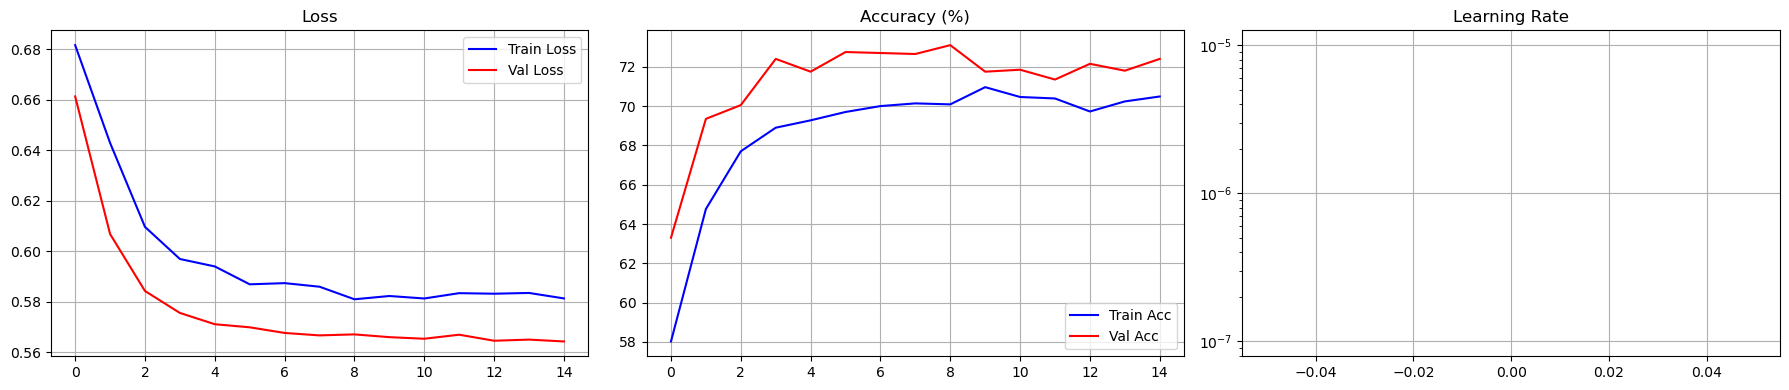

Best Validation Accuracy: 73.10%


NameError: name 'test_results' is not defined

In [40]:
fine_tune_model = train_classifier_model(model, train_loader, val_loader,num_epochs=15, lr=3e-5, patience=25)

# Fine tune (classification + regression)

In [47]:
class MultitaskHead(nn.Module):
    def __init__(self, encoder_dim=200, num_classes=2):  # Changed from 384 to 200
        super().__init__()
        self.shared = nn.Sequential(
            nn.LayerNorm(encoder_dim),  # Now expects [B, 200]
            nn.Linear(encoder_dim, 512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.1)
        )
        self.classifier = nn.Linear(256, num_classes)
        self.regressor = nn.Linear(256,1)
    
    def forward(self, features):
        shared = self.shared(features)
        cls_logits = self.classifier(shared)
        reg_pred = self.regressor(shared)
        return cls_logits,reg_pred

In [48]:
# fine tune model is set 
class MAE_Finetune(nn.Module):
    def __init__(self, pretrained_mae_path, img_size=125, patch_size=5, in_chans=8, 
                 num_classes=2, freeze_encoder=True):
        super().__init__()
        # Load pretrained MAE
        checkpoint = torch.load(pretrained_mae_path, map_location='cpu')
        pretrained_mae = mae(img_size=img_size, patch_size=patch_size, in_chans=in_chans)
        pretrained_mae.load_state_dict(checkpoint['model_state_dict'])
        
        # Extract encoder
        self.encoder = MAEEncoder(pretrained_mae)
        
        # Multi-task head
        self.head = MultitaskHead(encoder_dim=200, num_classes=num_classes)  # Adjust for small/base
        
        # Freeze encoder (optional - better for small datasets)
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
        
    def forward(self, x):
        features = self.encoder(x)
        cls_logits,reg_pred = self.head(features)
        return cls_logits,reg_pred
    
    def get_encoder_features(self, x):
        return self.encoder.forward_features(x)


In [55]:
def train_multitask(model, train_loader, val_loader, num_epochs=50, lr=1e-4, 
                   device='cuda', reg_lambda=1.0,cls_lambda=1.0 ,patience=10):
    model = model.to(device)
    optimizer = optim.AdamW(model.head.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    best_val_acc = 0
    patience_counter = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    for epoch in range(num_epochs):
        model.train()
        train_loss_total, train_correct, train_total = 0, 0, 0
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, cls_labels in train_pbar:
            images = images.to(device)
            cls_labels = cls_labels.to(device).squeeze(1).float()
            
            optimizer.zero_grad()
            cls_logits,reg_pred = model(images)
            cls_loss = F.binary_cross_entropy_with_logits(cls_logits[:, 1], cls_labels) 
            dummy_labels = torch.zeros_like(reg_pred)
            reg_loss = F.mse_loss(reg_pred,dummy_labels)
            total_loss = cls_lambda * cls_loss + reg_lambda * reg_loss
            total_loss.backward()
            optimizer.step()
            
            train_loss_total += total_loss.item()
            pred_cls = (cls_logits[:, 1] > 0).float()
            train_correct += (pred_cls == cls_labels).sum().item()
            train_total += cls_labels.numel()
            
            train_pbar.set_postfix({
                'loss': f'{total_loss.item():.4f}',
                'acc': f'{100*train_correct/train_total:.1f}%',
                'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
            })
        
        model.eval()
        val_loss_total, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc='Validation')
            for images, cls_labels in val_pbar:
                images = images.to(device)
                cls_labels = cls_labels.to(device).squeeze(1).float()
                cls_logits,reg_pred = model(images)
                cls_loss = F.binary_cross_entropy_with_logits(cls_logits[:, 1], cls_labels) 
                dummy_labels = torch.zeros_like(reg_pred)
                reg_loss = F.mse_loss(reg_pred,dummy_labels)
                total_loss = cls_lambda * cls_loss + reg_lambda * reg_loss            
                val_loss_total += total_loss.item()
                pred_cls = (cls_logits[:, 1] > 0).float()
                val_correct += (pred_cls == cls_labels).sum().item()
                val_total += cls_labels.numel()
        
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        avg_train_loss = train_loss_total / len(train_loader)
        avg_val_loss = val_loss_total / len(val_loader)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        scheduler.step()
        
        print(f'Epoch {epoch+1:2d}/{num_epochs} | '
              f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | '
              f'LR: {optimizer.param_groups[0]["lr"]:.2e}')
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'val_acc': val_acc,
                'epoch': epoch,
            }, 'best_mass_classifier_cls_ped.pth')
            print(f'New best model saved! Val Acc: {val_acc:.2f}%')
        else:
            patience_counter += 1
            print(f'Patience: {patience_counter}/{patience}')
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
    
    ax1.plot(train_losses, 'b-', label='Train Loss')
    ax1.plot(val_losses, 'r-', label='Val Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(train_accs, 'b-', label='Train Acc')
    ax2.plot(val_accs, 'r-', label='Val Acc')
    ax2.set_title('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    ax3.plot([group['lr'] for group in optimizer.param_groups], 'g-')
    ax3.set_title('Learning Rate')
    ax3.set_yscale('log')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f'Best Validation Accuracy: {best_val_acc:.2f}%')
    return model

In [56]:
model = MAE_Finetune(
    pretrained_mae_path=final_path,
    img_size=125, patch_size=5, in_chans=8,
    num_classes=2,  # Binary classification
    freeze_encoder=True  # Freeze encoder, train only head
)

Epoch 1/15:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  1/15 | Train Loss: 0.2968 | Train Acc: 69.30% | Val Loss: 0.2870 | Val Acc: 72.35% | LR: 2.97e-05
New best model saved! Val Acc: 72.35%


Epoch 2/15:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  7/15 | Train Loss: 0.2905 | Train Acc: 70.49% | Val Loss: 0.2833 | Val Acc: 71.15% | LR: 1.70e-05
Patience: 4/5


Epoch 8/15:   0%|          | 0/500 [00:00<?, ?it/s]

Validation:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch  8/15 | Train Loss: 0.2908 | Train Acc: 70.33% | Val Loss: 0.2820 | Val Acc: 72.70% | LR: 1.40e-05
Patience: 5/5
Early stopping at epoch 8


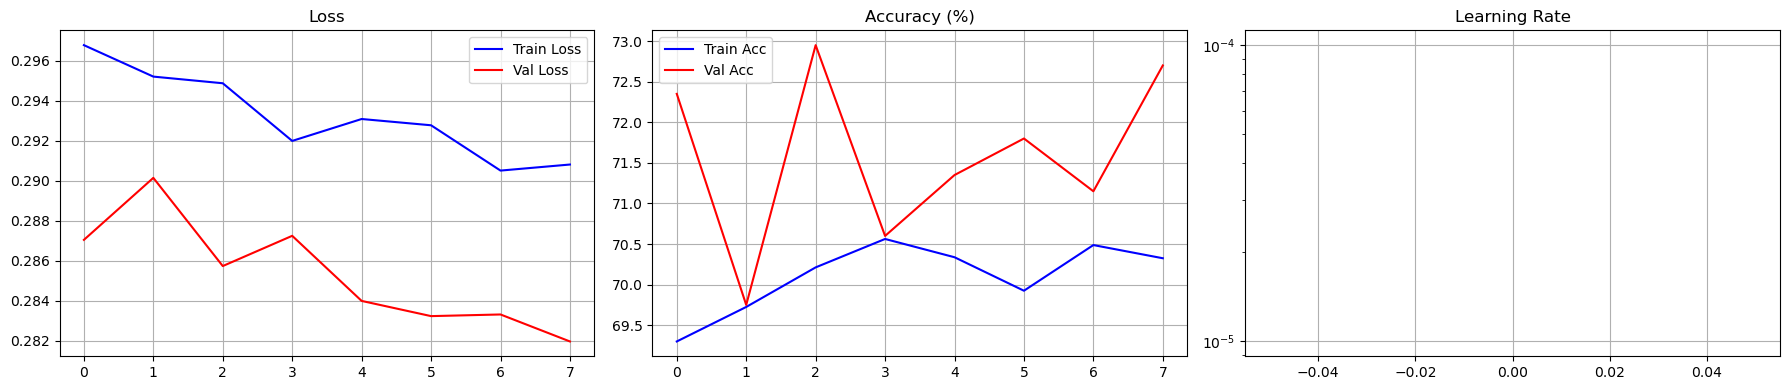

Best Validation Accuracy: 72.95%


In [58]:
fine_tune_model = train_multitask(model, train_loader, val_loader,num_epochs=15, lr=3e-5,reg_lambda=0.5,cls_lambda=0.5,patience=5)